# THY Cabin Knowledge Assistant — Production LangGraph RAG Architecture

This notebook is the executable architecture walkthrough for the current production RAG graph. It imports the real graph builders, renders the root graph and both subgraphs, inspects the shared state contract, and verifies terminal routing without calling OpenAI or Qdrant by default.

## Goal

- Make graph topology and state transitions reviewable by advanced AI engineers.
- Keep the notebook synchronized with `model/agentic_rag/` rather than maintaining a second graph.
- Demonstrate grounded, repaired, hybrid, general-knowledge, strict no-answer, and provider-failure routes.
- Keep owner-scoped retrieval, citation validation, and explicit no-answer behavior visible as trust boundaries.

> **Default execution is offline and deterministic.** The optional connected cell runs only when `RUN_CONNECTED_RAG_NOTEBOOK=1` is explicitly configured.

## Setup

The setup locates the repository root whether Jupyter starts from the project root or the `notebook/` directory. It reports only capability flags; secret values are never printed.

In [1]:
from __future__ import annotations

import html
import inspect
import os
import sys
from dataclasses import replace
from pathlib import Path

from IPython.display import Code, HTML, Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "model").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "model" / "agentic_rag").is_dir():
    raise RuntimeError(f"Could not locate the project root from {Path.cwd()}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model.agentic_rag.adapters import create_fake_adapters, create_openai_qdrant_adapters
from model.agentic_rag.graphs import (
    build_answer_subgraph,
    build_rag_graph,
    build_retrieval_subgraph,
)
from model.agentic_rag.nodes import (
    RagNodeSet,
    route_after_answer,
    route_after_general_generation,
    route_after_grounding_reflection,
    route_after_query_understanding,
    route_after_retrieval,
)
from model.agentic_rag.runner import run_rag_question
from model.agentic_rag.schemas import (
    Citation,
    CitationValidationResult,
    NodeError,
    RagState,
    ReflectionResult,
)
from model.agentic_rag.settings import RagSettings

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"OpenAI credentials configured: {bool(os.getenv('OPENAI_API_KEY'))}")
print(f"Qdrant endpoint configured: {bool(os.getenv('QDRANT_URL'))}")

Project root: <project-root>
Python: 3.12.4
OpenAI credentials configured: False
Qdrant endpoint configured: False


In [2]:
CARD_CSS = """
<style>
.architecture-card-grid { display:grid; grid-template-columns:repeat(2,minmax(0,1fr)); gap:14px; margin:14px 0 22px; }
.architecture-card { border:1px solid #d7dee8; border-radius:12px; padding:15px 16px; background:#fff; box-shadow:0 2px 8px rgba(20,33,61,.04); }
.architecture-card h4 { margin:0 0 8px; color:#14213d; font-size:15px; }
.architecture-card p { margin:0; color:#43516a; line-height:1.55; }
.architecture-card code { color:#9f1239; background:#fff1f2; padding:1px 4px; border-radius:4px; }
.architecture-card--risk { border-top:3px solid #c8102e; }
.architecture-card--value { border-top:3px solid #2563eb; }
.architecture-table { width:100%; border-collapse:collapse; margin:8px 0 18px; font-size:13px; }
.architecture-table th { background:#14213d; color:white; text-align:left; padding:8px; }
.architecture-table td { border:1px solid #d7dee8; padding:8px; vertical-align:top; }
.architecture-table tr:nth-child(even) td { background:#f8fafc; }
@media (max-width: 800px) { .architecture-card-grid { grid-template-columns:1fr; } }
</style>
"""
display(HTML(CARD_CSS))

def insight_cards(left_title: str, left_body: str, right_title: str, right_body: str) -> None:
    display(HTML(f"""
    <div class="architecture-card-grid">
      <section class="architecture-card architecture-card--value">
        <h4>{html.escape(left_title)}</h4><p>{left_body}</p>
      </section>
      <section class="architecture-card architecture-card--risk">
        <h4>{html.escape(right_title)}</h4><p>{right_body}</p>
      </section>
    </div>
    """))

def display_table(headers: list[str], rows: list[list[object]]) -> None:
    head = "".join(f"<th>{html.escape(str(value))}</th>" for value in headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{html.escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )
    display(HTML(f'<table class="architecture-table"><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>'))

## Build the Real Production Graphs

The offline settings select fake provider adapters but preserve the production graph, state type, node implementations, and route functions. `allowed_document_ids` is deliberately nonempty so document retrieval remains reachable in topology and deterministic demos.

In [3]:
offline_settings = RagSettings(
    self_service_llm_model="offline-fake-model",
    reranker_model="offline-fake-reranker",
    enable_reranker=False,
    allowed_document_ids=("notebook-document",),
)
offline_adapters = create_fake_adapters(offline_settings)
nodes = RagNodeSet(adapters=offline_adapters, settings=offline_settings)

retrieval_graph = build_retrieval_subgraph(nodes)
answer_graph = build_answer_subgraph(nodes)
root_graph = build_rag_graph(adapters=offline_adapters, settings=offline_settings)

root_drawable = root_graph.get_graph(xray=1)
retrieval_drawable = retrieval_graph.get_graph(xray=1)
answer_drawable = answer_graph.get_graph(xray=1)

print(f"Expanded root graph: {len(root_drawable.nodes)} nodes, {len(root_drawable.edges)} edges")
print(f"Retrieval subgraph: {len(retrieval_drawable.nodes)} nodes, {len(retrieval_drawable.edges)} edges")
print(f"Answer subgraph: {len(answer_drawable.nodes)} nodes, {len(answer_drawable.edges)} edges")

Expanded root graph: 18 nodes, 25 edges
Retrieval subgraph: 7 nodes, 6 edges
Answer subgraph: 6 nodes, 6 edges


In [4]:
display(Markdown("### Production builder source"))
display(Code(inspect.getsource(build_rag_graph), language="python"))

### Production builder source

def build_rag_graph(
    adapters: RagAdapters | None = None,
    settings: RagSettings | None = None,
    *,
    checkpointer=None,
    use_memory_saver: bool = False,
):
    """Build the main Agentic RAG graph with modular subgraphs."""

    settings = settings or RagSettings.from_env()
    adapters = adapters or create_fake_adapters(settings)
    nodes = RagNodeSet(adapters=adapters, settings=settings)
    retrieval_subgraph = build_retrieval_subgraph(nodes)
    answer_subgraph = build_answer_subgraph(nodes)

    builder = StateGraph(RagState)
    builder.add_node("query_understanding", nodes.query_understanding)
    builder.add_node("retrieval_subgraph", retrieval_subgraph)
    builder.add_node("answer_subgraph", answer_subgraph)
    builder.add_node("conversation_generation", nodes.conversation_generation)
    builder.add_node(
        "general_knowledge_generation",
        nodes.general_knowledge_generation,
    )
    builder.add_node(
        "compose_hybrid_response",
        _as_async(nodes.compose_hybrid_response),
    )
    builder.add_node("explicit_no_answer", _as_async(nodes.explicit_no_answer))
    builder.add_node("final_response", _as_async(nodes.final_response))

    builder.add_edge(START, "query_understanding")
    builder.add_conditional_edges(
        "query_understanding",
        _as_async(route_after_query_understanding),
        {
            "retrieval_subgraph": "retrieval_subgraph",
            "conversation_generation": "conversation_generation",
            "explicit_no_answer": "explicit_no_answer",
        },
    )
    builder.add_conditional_edges(
        "retrieval_subgraph",
        _as_async(route_after_retrieval),
        {
            "answer_subgraph": "answer_subgraph",
            "general_knowledge_generation": "general_knowledge_generation",
            "explicit_no_answer": "explicit_no_answer",
        },
    )
    builder.add_conditional_edges(
        "answer_subgraph",
        _as_async(route_after_answer),
        {
            "final_response": "final_response",
            "general_knowledge_generation": "general_knowledge_generation",
            "explicit_no_answer": "explicit_no_answer",
        },
    )
    builder.add_conditional_edges(
        "general_knowledge_generation",
        _as_async(route_after_general_generation),
        {
            "compose_hybrid_response": "compose_hybrid_response",
            "final_response": "final_response",
        },
    )
    builder.add_edge("compose_hybrid_response", "final_response")
    builder.add_edge("conversation_generation", "final_response")
    builder.add_edge("explicit_no_answer", "final_response")
    builder.add_edge("final_response", END)

    active_checkpointer = checkpointer
    if use_memory_saver and active_checkpointer is None:
        active_checkpointer = MemorySaver()
    return builder.compile(
        checkpointer=active_checkpointer,
        name="thy_agentic_rag_graph",
    )

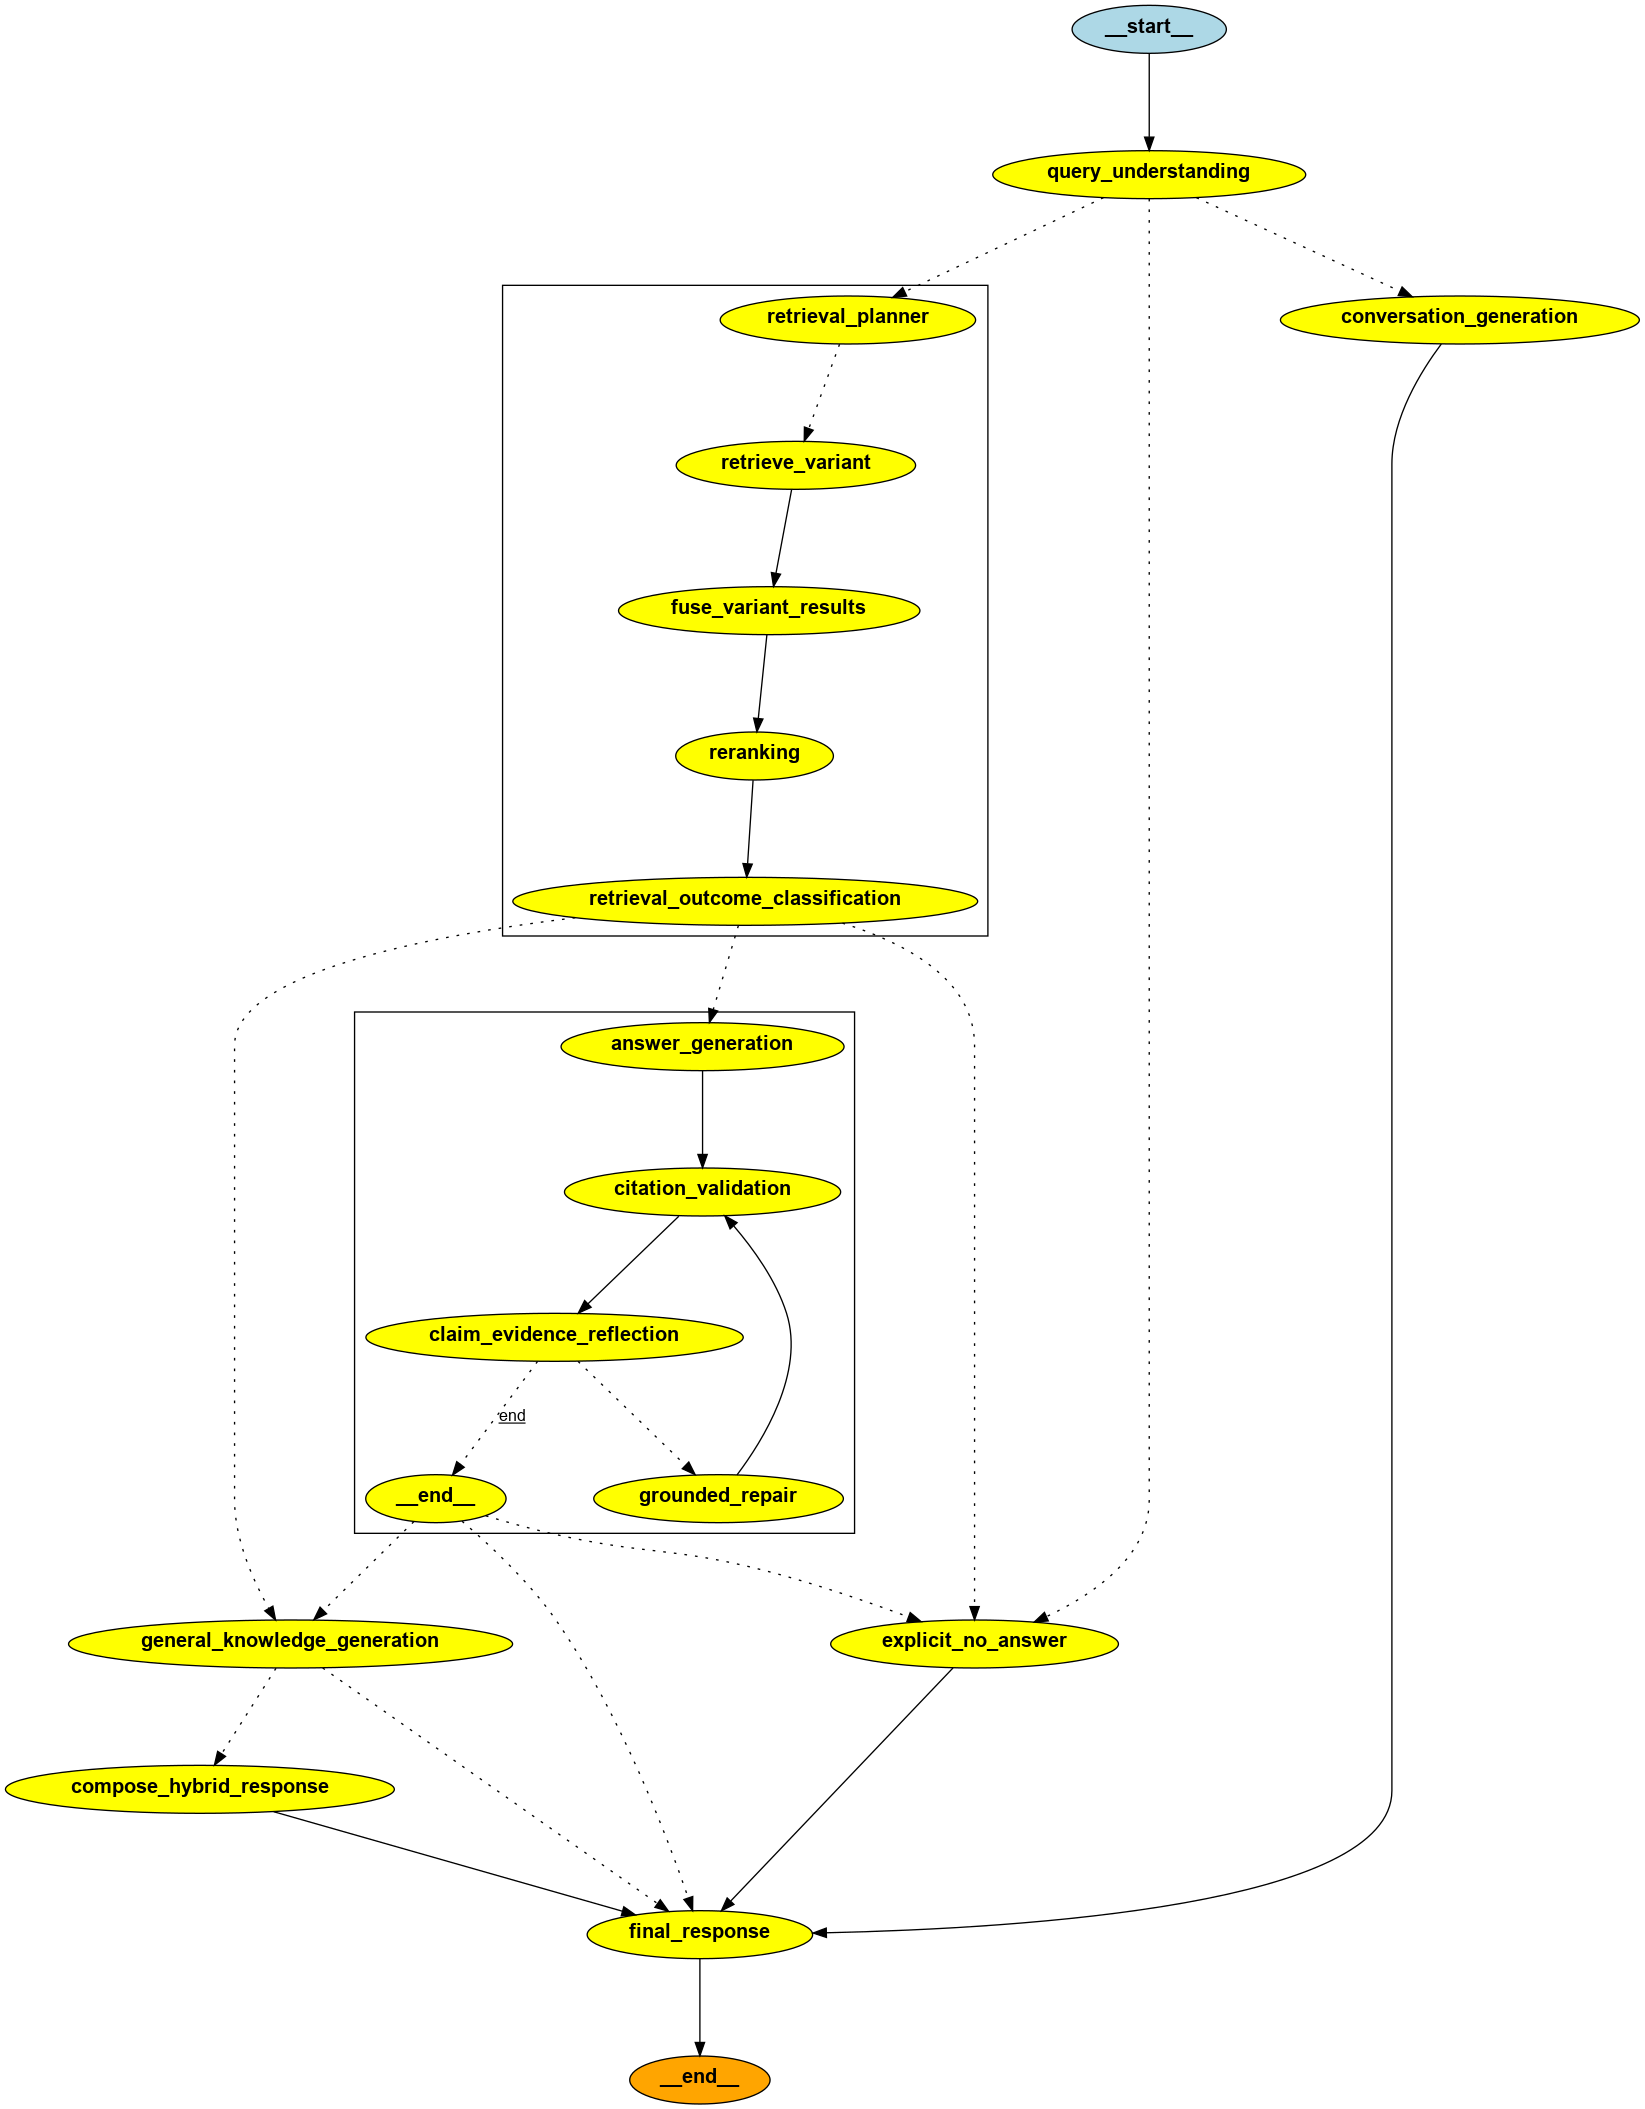

In [5]:
display(Image(data=root_drawable.draw_png(), format="png"))

In [6]:
insight_cards(
    "Why this matters in LangGraph",
    "The root graph keeps retrieval, grounded answering, conversational history, and general-knowledge fallback as explicit routes. Subgraphs isolate complexity while the root graph retains one auditable terminal response builder.",
    "Implementation caution",
    "General knowledge is not a retrieval substitute. Fatal provider, ACL, payload, or vector-store errors route to <code>explicit_no_answer</code>; they must never silently unlock model-memory fallback.",
)

## Retrieval Subgraph

The retrieval subgraph plans collection scope, dispatches one or two query variants with LangGraph `Send`, performs owner-scoped dense+sparse retrieval, fuses variant rankings deterministically, reranks evidence, and classifies whether the result may proceed.

def build_retrieval_subgraph(nodes: RagNodeSet):
    """Build adaptive one-or-two-query mapping, fusion, and reranking."""

    builder = StateGraph(RagState)
    builder.add_node("retrieval_planner", _as_async(nodes.retrieval_planner))
    builder.add_node("retrieve_variant", nodes.retrieve_variant)
    builder.add_node(
        "fuse_variant_results",
        _as_async(nodes.fuse_variant_results),
    )
    builder.add_node("reranking", nodes.reranking)
    builder.add_node(
        "retrieval_outcome_classification",
        _as_async(nodes.retrieval_outcome_classification),
    )
    builder.add_edge(START, "retrieval_planner")
    builder.add_conditional_edges(
        "retrieval_planner",
        _as_async(nodes.dispatch_query_variants),
        ["retrieve_variant"],
    )
    builder.add_edge("retrieve_variant", "fuse_variant_results")
    builder.add_edge("fuse_variant_results", "reranking")
    builder.add_edge("reranking", "retrieval_outcome_classification")
    builder.add_edge("retrieval_outcome_classification", END)
    return builder.compile(name="retrieval_subgraph")

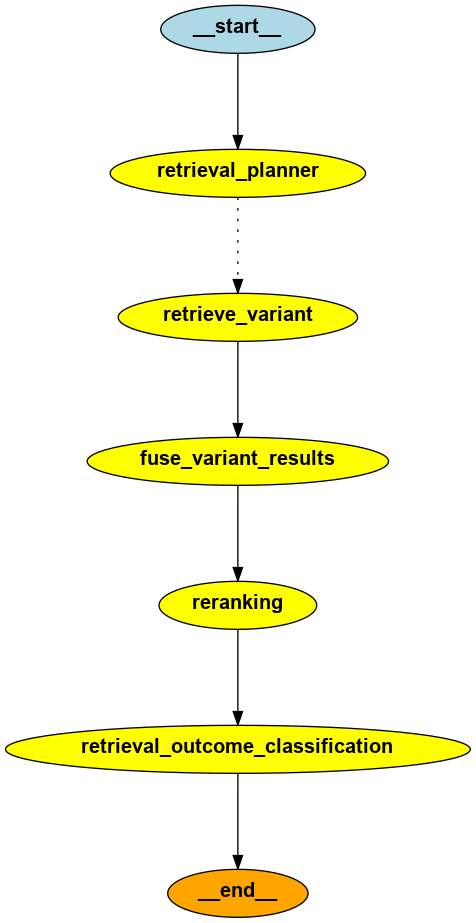

In [7]:
display(Code(inspect.getsource(build_retrieval_subgraph), language="python"))
display(Image(data=retrieval_drawable.draw_png(), format="png"))
insight_cards(
    "State mutation",
    "Parallel query-map workers return typed <code>VariantRetrievalResult</code> values. The reducer deduplicates them before deterministic fusion, so concurrent completion order cannot change the final candidate identity set.",
    "Failure boundary",
    "At least one selected collection must complete normally before a general fallback can be considered. Payload/ACL failures remain blocking even when another retrieval call returned normally.",
)

## Answer and Grounding Subgraph

The answer subgraph generates a document-grounded draft, validates exact citations, reflects on claim support and question coverage, and permits one bounded repair cycle. It cannot loop indefinitely.

def build_answer_subgraph(nodes: RagNodeSet):
    """Build the answer, citation validation, and reflection subgraph."""

    builder = StateGraph(RagState)
    builder.add_node("answer_generation", nodes.answer_generation)
    builder.add_node("citation_validation", _as_async(nodes.citation_validation))
    builder.add_node("claim_evidence_reflection", nodes.claim_evidence_reflection)
    builder.add_node("grounded_repair", nodes.grounded_repair)
    builder.add_edge(START, "answer_generation")
    builder.add_edge("answer_generation", "citation_validation")
    builder.add_edge("citation_validation", "claim_evidence_reflection")
    builder.add_conditional_edges(
        "claim_evidence_reflection",
        _as_async(route_after_grounding_reflection),
        {
            "grounded_repair": "grounded_repair",
            "end": END,
        },
    )
    builder.add_edge("grounded_repair", "citation_validation")
    return builder.compile(name="answer_subgraph")

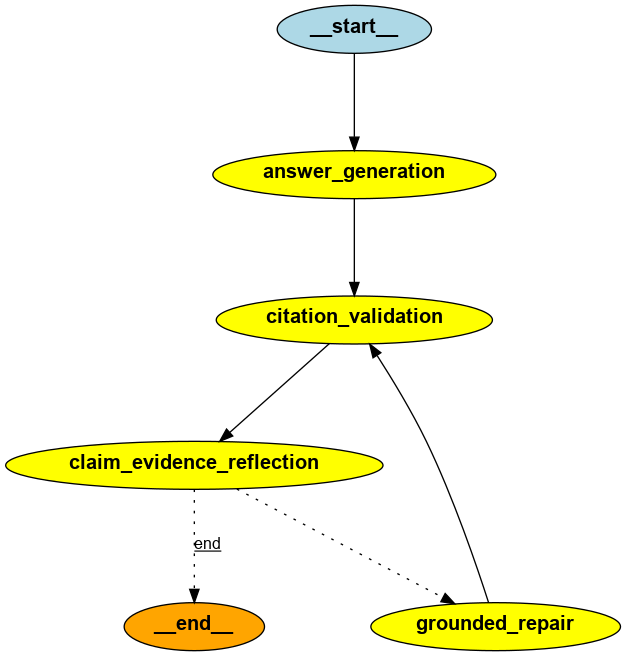

In [8]:
display(Code(inspect.getsource(build_answer_subgraph), language="python"))
display(Image(data=answer_drawable.draw_png(), format="png"))
insight_cards(
    "Why the repair cycle exists",
    "A valid evidence set can still produce an overbroad or poorly cited draft. One repair attempt recovers from that failure without repeating retrieval or creating an unbounded self-reflection loop.",
    "Implementation caution",
    "Repair is allowed only when deterministic citation validation passed and a structured reflection exists. A second rejection terminates the subgraph and returns control to the root policy.",
)

## Node Inventory

In [9]:
NODE_RESPONSIBILITIES = {
    "query_understanding": ("root", "Normalize intent; reset turn-local state; optionally rewrite follow-up", "OpenAI only for optional rewrite", "Falls back to verbatim query"),
    "retrieval_planner": ("retrieval", "Select semantic/docling collections and retrieval limits", "None", "Typed deterministic plan"),
    "retrieve_variant": ("retrieval", "Embed and retrieve one query variant with owner/document filters", "OpenAI embeddings + Qdrant", "Collection-isolated errors"),
    "fuse_variant_results": ("retrieval", "Deduplicate and weighted-RRF fuse map results", "None", "Stable total ordering"),
    "reranking": ("retrieval", "Structured OpenAI evidence scoring and sufficiency gate", "OpenAI reranker", "Typed node error; no invented evidence"),
    "retrieval_outcome_classification": ("retrieval", "Classify success, fatal errors, evidence, and fallback eligibility", "None", "Fail closed on unsafe errors"),
    "answer_generation": ("answer", "Generate cited document-only draft", "OpenAI chat model", "No citation means no grounded acceptance"),
    "citation_validation": ("answer", "Validate exact evidence IDs and owner scope", "None", "Reject unknown/cross-owner citations"),
    "claim_evidence_reflection": ("answer", "Evaluate support, hallucination risk, and coverage", "OpenAI structured evaluator", "Routes to repair or terminal"),
    "grounded_repair": ("answer", "Repair the grounded draft once", "OpenAI chat model", "Bounded by state flag"),
    "conversation_generation": ("root", "Answer explicit session-history questions", "OpenAI chat model", "No document citations"),
    "general_knowledge_generation": ("root", "Generate isolated labeled model knowledge", "OpenAI chat model", "Forbidden for private/file-specific facts"),
    "compose_hybrid_response": ("root", "Join grounded and general sections with fixed labels", "None", "Citations remain grounded-section only"),
    "explicit_no_answer": ("root", "Build deterministic document no-answer", "None", "Empty citations"),
    "final_response": ("root", "Build typed terminal response", "None", "Last citation/no-answer gate"),
}

rows = []
for node_name in sorted(NODE_RESPONSIBILITIES):
    scope, responsibility, provider, failure = NODE_RESPONSIBILITIES[node_name]
    rows.append([node_name, scope, responsibility, provider, failure])
display_table(["Node", "Scope", "Responsibility", "Provider boundary", "Failure behavior"], rows)

Node,Scope,Responsibility,Provider boundary,Failure behavior
answer_generation,answer,Generate cited document-only draft,OpenAI chat model,No citation means no grounded acceptance
citation_validation,answer,Validate exact evidence IDs and owner scope,None,Reject unknown/cross-owner citations
claim_evidence_reflection,answer,"Evaluate support, hallucination risk, and coverage",OpenAI structured evaluator,Routes to repair or terminal
compose_hybrid_response,root,Join grounded and general sections with fixed labels,None,Citations remain grounded-section only
conversation_generation,root,Answer explicit session-history questions,OpenAI chat model,No document citations
explicit_no_answer,root,Build deterministic document no-answer,None,Empty citations
final_response,root,Build typed terminal response,None,Last citation/no-answer gate
fuse_variant_results,retrieval,Deduplicate and weighted-RRF fuse map results,None,Stable total ordering
general_knowledge_generation,root,Generate isolated labeled model knowledge,OpenAI chat model,Forbidden for private/file-specific facts
grounded_repair,answer,Repair the grounded draft once,OpenAI chat model,Bounded by state flag


## Shared `RagState` Contract

In [10]:
STATE_GROUPS = {
    "Request and conversation": ["user_id", "thread_id", "collection_scope", "conversation_history", "question"],
    "Query understanding": ["normalized_question", "retrieval_query", "retrieval_turn_sequence", "query_variants", "query_variant", "query_intent", "documents_available"],
    "Retrieval": ["retrieval_plan", "variant_results", "retrieved_chunks", "reranked_chunks", "retrieval_succeeded", "successful_retrieval_collections", "failed_retrieval_collections", "evidence_sufficient", "checked_collections"],
    "Grounded answer": ["draft_answer", "grounded_draft", "grounded_repair_attempted", "grounded_repair_feedback", "grounded_answer", "citations", "citation_validation", "reflection"],
    "Fallback and terminal": ["general_knowledge_answer", "fallback_eligible", "fallback_reason", "response_mode", "final_answer", "response", "no_answer", "errors"],
}

annotations = RagState.__annotations__
state_rows = []
covered = set()
for group, fields in STATE_GROUPS.items():
    for field in fields:
        if field not in annotations:
            raise AssertionError(f"Notebook state field drift: {field}")
        covered.add(field)
        state_rows.append([group, field, str(annotations[field])])
unclassified = sorted(set(annotations).difference(covered))
assert not unclassified, f"Unclassified RagState fields: {unclassified}"
display_table(["State group", "Field", "Runtime annotation"], state_rows)

State group,Field,Runtime annotation
Request and conversation,user_id,"ForwardRef('str', module='model.agentic_rag.schemas')"
Request and conversation,thread_id,"ForwardRef('str | None', module='model.agentic_rag.schemas')"
Request and conversation,collection_scope,"ForwardRef('CollectionScope', module='model.agentic_rag.schemas')"
Request and conversation,conversation_history,"ForwardRef('list[ConversationTurn]', module='model.agentic_rag.schemas')"
Request and conversation,question,"ForwardRef('str', module='model.agentic_rag.schemas')"
Query understanding,normalized_question,"ForwardRef('str', module='model.agentic_rag.schemas')"
Query understanding,retrieval_query,"ForwardRef('str', module='model.agentic_rag.schemas')"
Query understanding,retrieval_turn_sequence,"ForwardRef('int', module='model.agentic_rag.schemas')"
Query understanding,query_variants,"ForwardRef('list[QueryVariant]', module='model.agentic_rag.schemas')"
Query understanding,query_variant,"ForwardRef('QueryVariant', module='model.agentic_rag.schemas')"


## Routing Decision Matrix

In [11]:
route_rows = [
    ["History request", "Session context", "conversation_generation", "conversational", "No"],
    ["Sufficient grounded evidence", "Uploaded documents", "answer_subgraph → final_response", "grounded", "Required"],
    ["Grounded but partial coverage", "Documents + eligible model knowledge", "general_knowledge_generation → compose_hybrid_response", "hybrid", "Document section only"],
    ["No acceptable evidence; general question", "Labeled model knowledge", "general_knowledge_generation → final_response", "general_knowledge", "Forbidden"],
    ["Private/file-specific question without evidence", "None", "explicit_no_answer → final_response", "no answer", "Empty"],
    ["Fatal provider/ACL/payload failure", "None", "explicit_no_answer → final_response", "service-safe no answer", "Empty"],
]
display_table(["Condition", "Answer source", "Route", "Mode", "Citations"], route_rows)

Condition,Answer source,Route,Mode,Citations
History request,Session context,conversation_generation,conversational,No
Sufficient grounded evidence,Uploaded documents,answer_subgraph → final_response,grounded,Required
Grounded but partial coverage,Documents + eligible model knowledge,general_knowledge_generation → compose_hybrid_response,hybrid,Document section only
No acceptable evidence; general question,Labeled model knowledge,general_knowledge_generation → final_response,general_knowledge,Forbidden
Private/file-specific question without evidence,None,explicit_no_answer → final_response,no answer,Empty
Fatal provider/ACL/payload failure,None,explicit_no_answer → final_response,service-safe no answer,Empty


## Deterministic Offline Route Checks

These checks exercise the production route functions directly. They prove routing invariants without making network calls or claiming retrieval-quality benchmark results.

In [12]:
valid_citations = CitationValidationResult(
    is_valid=True,
    cited_chunk_ids=["chunk-1"],
)
accepted_full = ReflectionResult(
    is_grounded=True,
    hallucination_risk="low",
    decision="accept",
    question_coverage="full",
)
accepted_partial = accepted_full.model_copy(update={"question_coverage": "partial"})
needs_revision = ReflectionResult(
    is_grounded=False,
    hallucination_risk="medium",
    decision="revise",
    question_coverage="partial",
    unsupported_claims=["One claim is broader than the cited evidence."],
)
citation = Citation(
    document_name="manual.pdf",
    document_id="document-1",
    page_number=4,
    chunk_id="chunk-1",
    source_excerpt="Grounded evidence.",
    retrieval_score=0.91,
    collection_name="semantic_chunks",
    ingestion_method="semantic",
    source_pipeline="semantic_image_chunking",
)

route_checks = [
    ("history bypass", route_after_query_understanding({"query_intent": "conversation_history"}), "conversation_generation"),
    ("no documents", route_after_query_understanding({"documents_available": False}), "explicit_no_answer"),
    ("document retrieval", route_after_query_understanding({"documents_available": True}), "retrieval_subgraph"),
    ("sufficient evidence", route_after_retrieval({"evidence_sufficient": True, "errors": []}), "answer_subgraph"),
    ("eligible empty evidence", route_after_retrieval({"fallback_eligible": True, "errors": []}), "general_knowledge_generation"),
    ("fatal retrieval error", route_after_retrieval({"fallback_eligible": True, "errors": [NodeError(node="reranking", message="provider failure")]}), "explicit_no_answer"),
    ("accepted grounded answer", route_after_answer({"citation_validation": valid_citations, "reflection": accepted_full, "citations": [citation], "errors": []}), "final_response"),
    ("accepted partial answer", route_after_answer({"citation_validation": valid_citations, "reflection": accepted_partial, "citations": [citation], "fallback_eligible": True, "errors": []}), "general_knowledge_generation"),
    ("first grounded repair", route_after_grounding_reflection({"citation_validation": valid_citations, "reflection": needs_revision, "grounded_repair_attempted": False, "errors": []}), "grounded_repair"),
    ("bounded repair termination", route_after_grounding_reflection({"citation_validation": valid_citations, "reflection": needs_revision, "grounded_repair_attempted": True, "errors": []}), "end"),
    ("hybrid composition", route_after_general_generation({"grounded_answer": "Grounded.", "general_knowledge_answer": "General."}), "compose_hybrid_response"),
    ("general-only final", route_after_general_generation({"general_knowledge_answer": "General."}), "final_response"),
]

for label, actual, expected in route_checks:
    assert actual == expected, f"{label}: expected {expected}, received {actual}"
display_table(["Scenario", "Observed route", "Expected route"], [[label, actual, expected] for label, actual, expected in route_checks])
print(f"Verified {len(route_checks)} production routing invariants.")

Scenario,Observed route,Expected route
history bypass,conversation_generation,conversation_generation
no documents,explicit_no_answer,explicit_no_answer
document retrieval,retrieval_subgraph,retrieval_subgraph
sufficient evidence,answer_subgraph,answer_subgraph
eligible empty evidence,general_knowledge_generation,general_knowledge_generation
fatal retrieval error,explicit_no_answer,explicit_no_answer
accepted grounded answer,final_response,final_response
accepted partial answer,general_knowledge_generation,general_knowledge_generation
first grounded repair,grounded_repair,grounded_repair
bounded repair termination,end,end


Verified 12 production routing invariants.


In [13]:
expected_root_nodes = {
    "query_understanding",
    "conversation_generation",
    "general_knowledge_generation",
    "compose_hybrid_response",
    "explicit_no_answer",
    "final_response",
}
expanded_node_ids = set(root_drawable.nodes)
missing_root_nodes = expected_root_nodes.difference(expanded_node_ids)
assert not missing_root_nodes, f"Missing production graph nodes: {sorted(missing_root_nodes)}"
assert "retrieval_subgraph:reranking" in expanded_node_ids
assert "answer_subgraph:grounded_repair" in expanded_node_ids
assert len(root_drawable.edges) >= 20
print("Topology checks passed: root routes, retrieval reranking, and bounded grounded repair are present.")

Topology checks passed: root routes, retrieval reranking, and bounded grounded repair are present.


## Checkpointing and Conversation Memory

The production runner hashes `(user_id, thread_id)` into an opaque checkpoint namespace. LangGraph memory is optional and session-scoped; it is not a document knowledge store and never replaces Qdrant retrieval.

In [14]:
memory_graph = build_rag_graph(
    adapters=offline_adapters,
    settings=offline_settings,
    use_memory_saver=True,
)
assert memory_graph.checkpointer is not None
print(f"Checkpointer: {type(memory_graph.checkpointer).__name__}")
insight_cards(
    "Why checkpointing is optional",
    "Document retrieval remains stateless and owner-filtered. Checkpoints retain bounded conversational state for one thread; they do not copy document chunks into model memory.",
    "Isolation requirement",
    "The backend must supply both the authenticated owner and an opaque thread namespace. A raw thread ID alone is not an acceptable cross-user checkpoint key.",
)

Checkpointer: InMemorySaver


## Optional Connected Smoke Check

This cell is disabled by default. It requires an explicit user, allowed document IDs already ingested for that user, OpenAI credentials, and Qdrant connectivity. It is an integration smoke check, not a retrieval-quality benchmark.

In [15]:
run_connected = os.getenv("RUN_CONNECTED_RAG_NOTEBOOK", "0").strip() == "1"
if not run_connected:
    print("SKIPPED: set RUN_CONNECTED_RAG_NOTEBOOK=1 and the NOTEBOOK_* variables to run the connected check.")
else:
    user_id = os.environ["NOTEBOOK_USER_ID"].strip()
    document_ids = tuple(
        value.strip()
        for value in os.environ["NOTEBOOK_ALLOWED_DOCUMENT_IDS"].split(",")
        if value.strip()
    )
    question = os.environ["NOTEBOOK_QUESTION"].strip()
    if not user_id or not document_ids or not question:
        raise RuntimeError("NOTEBOOK_USER_ID, NOTEBOOK_ALLOWED_DOCUMENT_IDS, and NOTEBOOK_QUESTION must be nonempty.")

    connected_settings = replace(
        RagSettings.from_env(),
        allowed_document_ids=document_ids,
    )
    connected_adapters = create_openai_qdrant_adapters(connected_settings)
    try:
        connected_response = await run_rag_question(
            question,
            user_id=user_id,
            thread_id="langgraph-architecture-notebook",
            adapters=connected_adapters,
            settings=connected_settings,
            collection_scope="both",
        )
    finally:
        await connected_adapters.aclose()

    print(f"No answer: {connected_response.no_answer}")
    print(f"Citation count: {len(connected_response.citations)}")
    display(Markdown(connected_response.answer))

SKIPPED: set RUN_CONNECTED_RAG_NOTEBOOK=1 and the NOTEBOOK_* variables to run the connected check.


## Checks and Next Steps

### Verified by the default execution

- The notebook imports production builders and route functions.
- Root, retrieval, and answer graphs compile and render locally.
- The full `RagState` contract is classified; new unclassified fields fail the notebook.
- Twelve terminal routing invariants pass without provider calls.
- Bounded grounded repair and optional checkpointing are present.

### Operational next steps

1. Run the repository unit/integration suites after any graph change.
2. Regenerate `docs/architecture/` with `scripts/generate_architecture_diagrams.py`.
3. Run the optional connected cell only against an isolated user/document scope.
4. Measure retrieval quality with the labeled evaluation fixture; do not infer Recall@K or answer accuracy from this architecture smoke notebook.